In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

df=pd.read_excel('superstore.xls')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-01,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
cols=['Discount','Profit','Quantity','Sales']
df[cols].describe()

,Discount,Profit,Quantity,Sales
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,0.156203,28.656896,3.789574,229.858001
std,0.206452,234.260108,2.225110,623.245101
min,0.000000,-6599.978000,1.000000,0.444000
25%,0.000000,1.728750,2.000000,17.280000
50%,0.200000,8.666500,3.000000,54.490000
75%,0.200000,29.364000,5.000000,209.940000
max,0.800000,8399.976000,14.000000,22638.480000


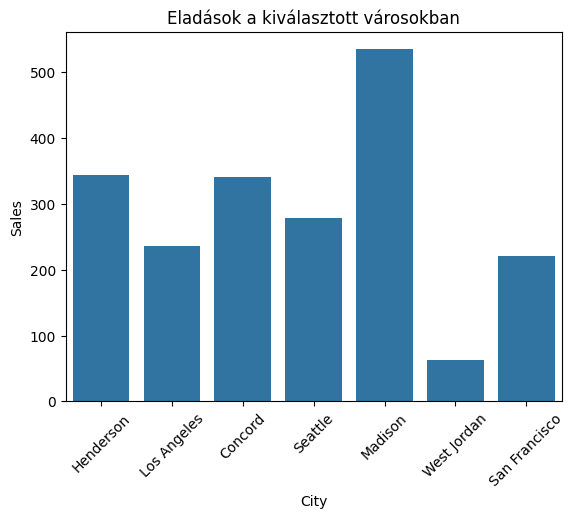

In [21]:
cities=['Henderson','Los Angeles','Seattle','San Francisco','West Jordan','Madison','Concord']
df_filtered=df[df['City'].isin(cities)]
sns.barplot(data=df_filtered,x='City',y='Sales',errorbar=None)
plt.title('Eladások a kiválasztott városokban')
plt.xticks(rotation=45)
plt.show()



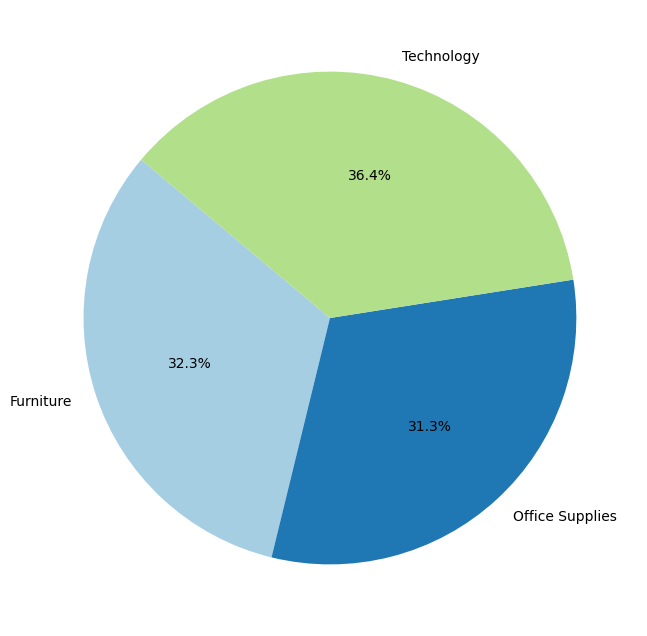

In [24]:

profit_per_category=df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(8,8))
plt.pie(profit_per_category,labels=profit_per_category.index,autopct='%1.1f%%',startangle=140,colors=plt.cm.Paired.colors)
plt.show()

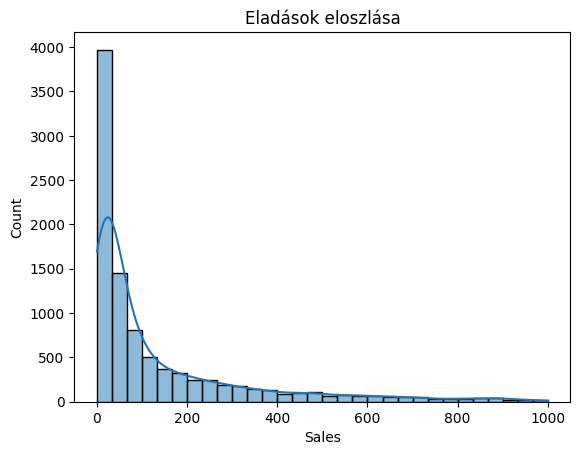

In [42]:
f_normal = df[df['Sales'] < 1000]

sns.histplot(data=f_normal, x='Sales', bins=30, kde=True)
plt.title('Eladások eloszlása')
plt.show()

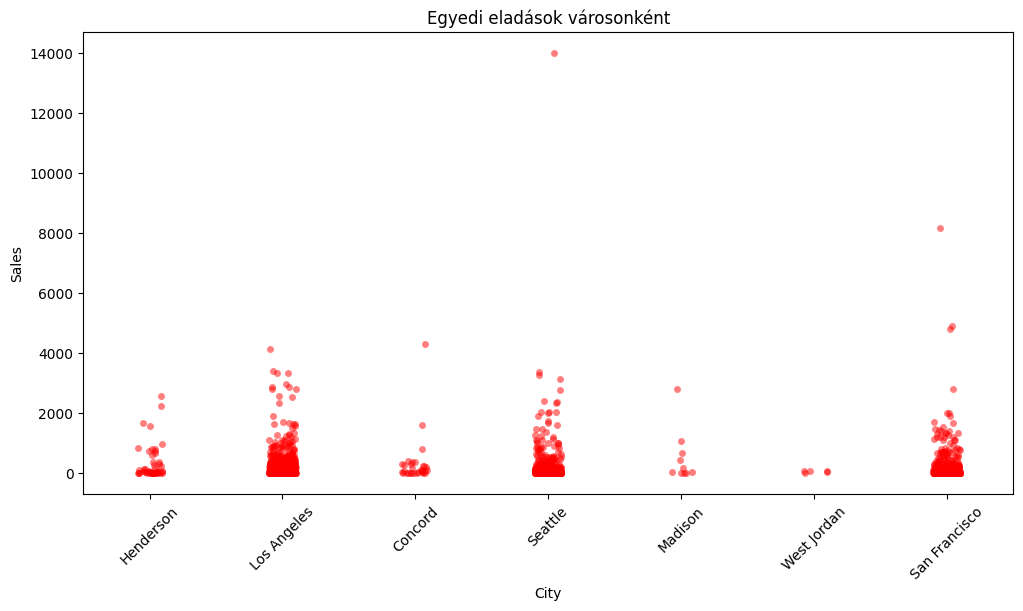

In [46]:
plt.figure(figsize=(12, 6))
sns.stripplot(data=df_filtered, x='City', y='Sales', jitter=True, alpha=0.5, color='red')
plt.xticks(rotation=45)
plt.title('Egyedi eladások városonként')
plt.show()

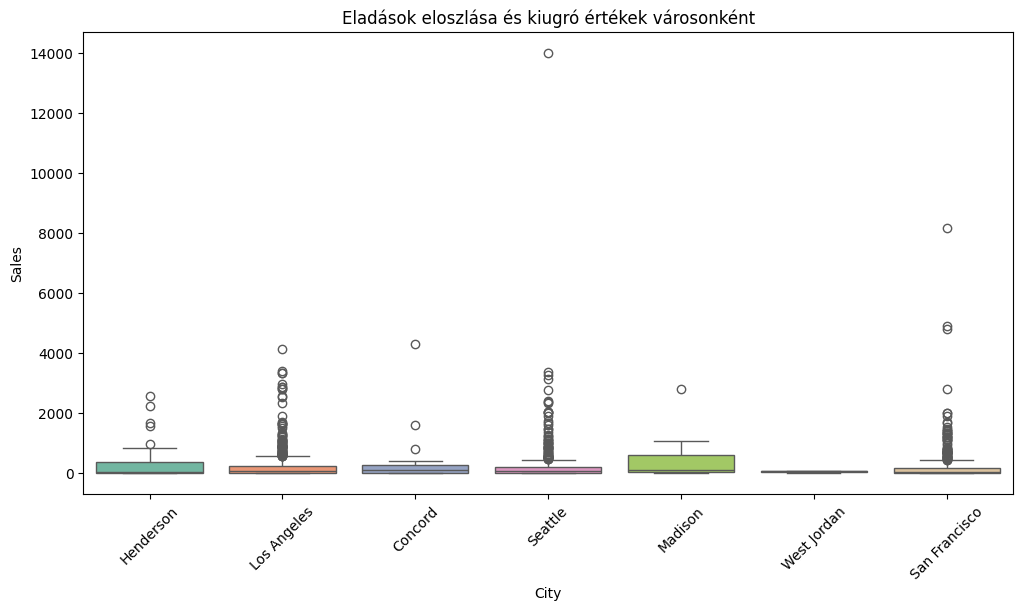

In [48]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered, x='City', y='Sales', hue='City',palette='Set2')
plt.title('Eladások eloszlása és kiugró értékek városonként')
plt.xticks(rotation=45)
plt.show()

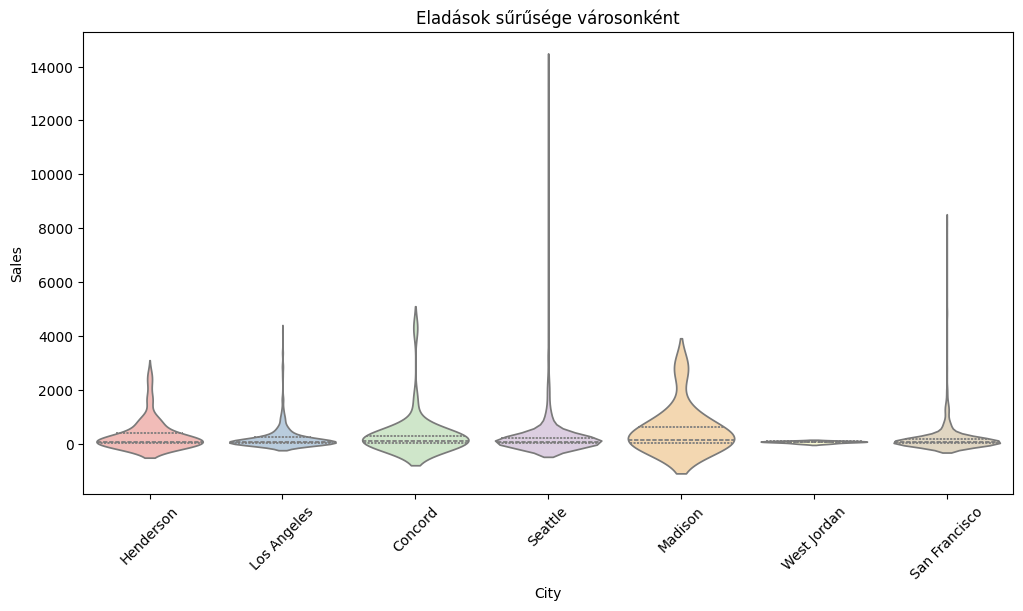

In [50]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_filtered, x='City', y='Sales', hue='City',inner='quartile', palette='Pastel1')
plt.title('Eladások sűrűsége városonként')
plt.xticks(rotation=45)
plt.show()

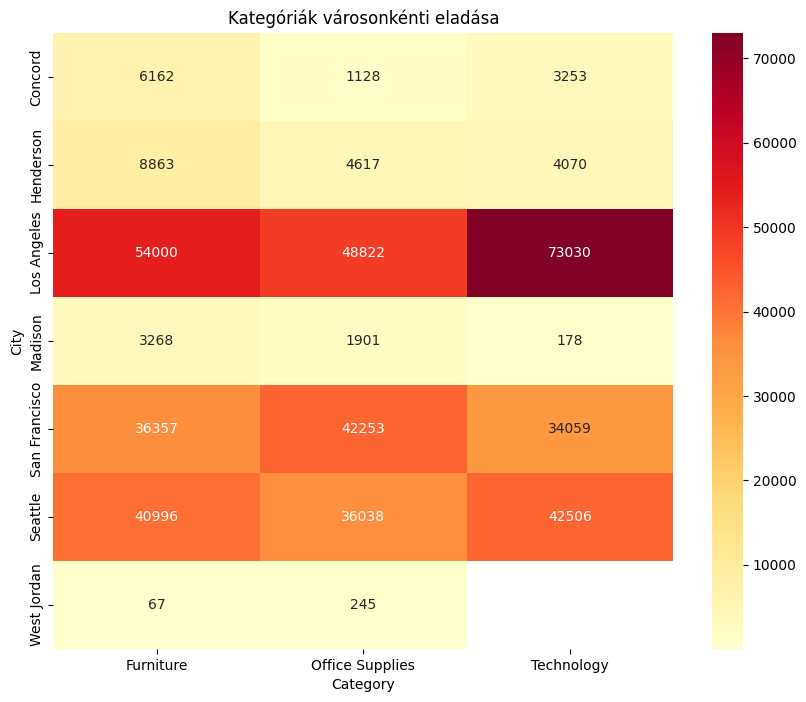

In [52]:

pivot_df = df_filtered.pivot_table(values='Sales', index='City', columns='Category', aggfunc='sum')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap='YlOrRd')
plt.title('Kategóriák városonkénti eladása')
plt.show()